***

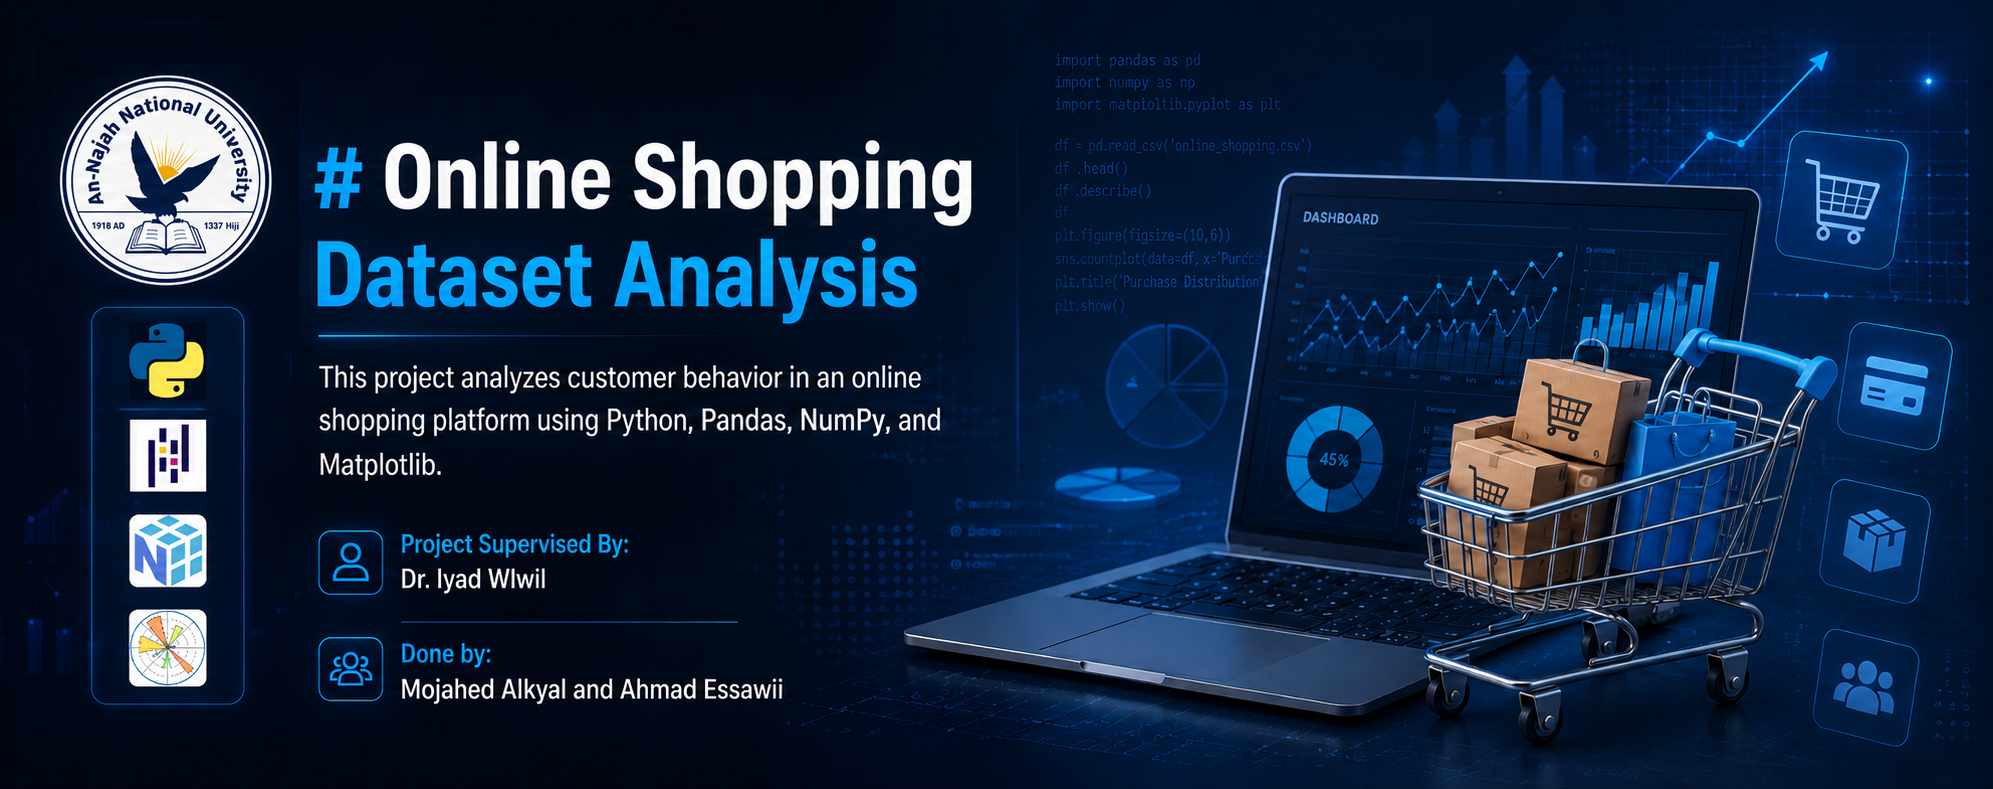

***

### 1.0. Importing Libraries

In this step, we import the essential libraries required for data manipulation and visualization:

* **Pandas (`pd`)**: Used for data structuring and analysis.
* **NumPy (`np`)**: Used for numerical computations and handling multi-dimensional arrays.
* **Matplotlib (`plt`)**: Used for creating static, interactive, and animated visualizations in Python.
* **Confirmation**: A success message is printed to verify that the Libraries have been imported successfully.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


***

### 2.0. Reading The DataSet

In this step, we load the dataset into our environment using Pandas:

* **`pd.read_csv()`**: Used to read the `"online_shopping.csv"` file and store it as a DataFrame named `df`.
* **Confirmation**: A success message is printed to verify that the dataset has been loaded properly without any issues.

In [4]:
df = pd.read_csv("online_shopping.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


***

### 3.0. Data Exploration
Before doing any analysis, we need to look at our data to understand its size, columns, and types.
* **`df.head()`**: Displays the first 5 rows of the dataset to give us a quick preview.
* **`df.info()`**: Shows a summary of the dataset, including the total number of rows, column names, and data types (numbers, text, etc.).

In [9]:
# Previewing the first 5 rows
df.head()

,age,gender,time_on_site,pages_viewed,device,purchase_amount,discount_used,click_rate,return_customer
0,63.0,Male,18.685621,3,mobile,289.253886,Yes,35.878814,1.0
1,43.0,Female,4.411306,9,Desktop,224.366091,No,177.625321,0.0
2,35.0,Male,9.217575,17,Mobile,254.559993,Yes,42.648411,0.0
3,NaN,Female,13.183255,4,Desktop,66.949884,No,34.546995,1.0
4,NaN,Female,17.709027,3,mobile,170.062225,Yes,56.095720,0.0


In [10]:
df.info()
# Checking dataset summary and types

<class 'pandas.DataFrame'>
RangeIndex: 588 entries, 0 to 587
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              544 non-null    float64
 1   gender           560 non-null    str    
 2   time_on_site     540 non-null    float64
 3   pages_viewed     582 non-null    str    
 4   device           545 non-null    str    
 5   purchase_amount  586 non-null    float64
 6   discount_used    583 non-null    str    
 7   click_rate       583 non-null    float64
 8   return_customer  560 non-null    float64
dtypes: float64(5), str(4)
memory usage: 41.5 KB


### 3.1. Statistical Summary
In this step, we generate descriptive statistics to understand the distribution, central tendency, and spread of our numerical data:
* **`df.describe()`**: Provides a summary of key statistical metrics for each numerical column, including:
  * **count**: The number of non-empty values (helps identify missing data).
  * **mean**: The average value of the column.
  * **std (Standard Deviation)**: Measures how spread out the values are from the mean.
  * **min / max**: The minimum and maximum values in the dataset.
  * **25%, 50%, 75% (Percentiles)**: Shows the distribution thresholds (where 50% is the Median).

In [8]:
df.describe() 

,age,time_on_site,purchase_amount,click_rate,return_customer
count,544.000000,540.000000,586.000000,583.000000,560.000000
mean,41.454044,9.780284,153.131772,100.174377,0.539286
std,13.198363,5.278244,86.507413,58.903691,0.498900
min,18.000000,-4.587980,10.051373,-57.312120,0.000000
25%,30.750000,6.064852,71.869455,58.592575,0.000000
50%,41.500000,9.508014,158.236823,101.150090,1.000000
75%,53.000000,13.160917,225.775529,141.780225,1.000000
max,64.000000,26.845768,299.310595,323.263948,1.000000


### 3.2. Dataset Shape
In this final exploration step, we check the overall size of our dataset:
* **`df.shape`**: Returns a tuple representing the dimensionality of the DataFrame in the format `(rows, columns)`. 
  * The first number represents the total number of **Rows** (samples/customers).
  * The second number represents the total number of **Columns** (features/attributes).

In [10]:
df.shape

(588, 9)

***

### 4.0. Column Name Standardization
Before cleaning the actual values, it is a best practice to clean the metadata (column names). In this step, we standardize the column titles to make them cleaner and easier to read:
* **`df.copy()`**: Creates a separate copy of our original DataFrame (named `dfc`) to safely apply changes without affecting the source data.
* **`.str.replace('_', ' ').str.title()`**: Replaces underscores with spaces and capitalizes the first letter of each word (e.g., `time_on_site` becomes `Time On Site`).
* **`.str.replace(' ', '')`**: Removes the spaces between words, combining them into clean CamelCase/PascalCase identifiers (e.g., `Time On Site` becomes `TimeOnSite`).

In [ ]:
dfc = df.copy()
dfc.columns = dfc.columns.str.replace('_', ' ').str.title()
dfc.columns = dfc.columns.str.replace(' ', '')
dfc.columns


Index(['Age', 'Gender', 'TimeOnSite', 'PagesViewed', 'Device',
       'PurchaseAmount', 'DiscountUsed', 'ClickRate', 'ReturnCustomer'],
      dtype='str')


 The dataset contains information about online shopping customers, including age, gender, time spent on the website, pages viewed, device type, purchase amount, discount usage, click rate, and whether the customer is returning or new.

### 4.1. Enforcing Correct Data Types & Handling Invalid Entries
Sometimes, numerical columns contain accidental text entries or corrupted characters, causing Pandas to treat the entire column as text (Object/String). In this step, we ensure that all analytical features are strictly numerical:
* **`pd.to_numeric(..., errors='coerce')`**: This function converts data into numerical formats. The critical argument **`errors='coerce'`** ensures that if the function encounters any invalid text or unexpected string within a numerical column, it will force-convert it into a missing value indicator (**`NaN`**), rather than throwing an error and stopping the code.
* **`dfc.isnull().sum()`**: This is rerun right after the conversion to check how many text anomalies were converted into `NaN`.

In [16]:
 # We Will Check The Data Set: 
 # If Cols  DataType numeric and has one value or more String => I Will Change It To NaN
 # If Cols  DataType String and has one value or more  numeric => I Will Change It To NaN

dfc['Age'] = pd.to_numeric(dfc['Age'], errors='coerce')
dfc['PagesViewed'] = pd.to_numeric(dfc['PagesViewed'], errors='coerce')
dfc['TimeOnSite'] = pd.to_numeric(dfc['TimeOnSite'], errors='coerce')
dfc['PurchaseAmount'] = pd.to_numeric(dfc['PurchaseAmount'], errors='coerce')
dfc['ClickRate'] = pd.to_numeric(dfc['ClickRate'], errors='coerce')
dfc['ReturnCustomer'] = pd.to_numeric(dfc['ReturnCustomer'], errors='coerce')
print("Columns Converted Successfully")

dfc.isnull().sum()


Columns Converted Successfully


Age               44
Gender            28
TimeOnSite        48
PagesViewed       36
Device            43
PurchaseAmount     2
DiscountUsed       5
ClickRate          5
ReturnCustomer    28
dtype: int64

### 4.2. Checking for Duplicated Rows
To wrap up our data cleaning process, we need to ensure that our dataset does not contain identical rows, which could bias our statistics and charts:
* **`dfc.duplicated().sum()`**: Scans the dataset to count how many rows are exact duplicates of other rows.
* **`dfc.shape`**: Prints the final dimensions (rows, columns) of the cleaned DataFrame, showing us the exact size of the data we will use for analysis.

In [15]:
sum = dfc.duplicated().sum()
shapedfc = dfc.shape
print(sum)
print(shapedfc)

18
(588, 9)


In [18]:
res = dfc[dfc.isnull().any(axis=1)]
res.shape


(204, 9)

In [19]:
twoNaN = dfc[dfc.isnull().sum(axis=1) >= 2]
twoNaN.shape


(33, 9)

In [21]:
dfc['Age'] = dfc['Age'].fillna(dfc['Age'].median())

dfc['Gender'] = dfc['Gender'].fillna(dfc['Gender'].mode()[0])

dfc['TimeOnSite'] = dfc['TimeOnSite'].fillna(dfc['TimeOnSite'].median())

dfc['PagesViewed'] = dfc['PagesViewed'].fillna(dfc['PagesViewed'].median())

dfc['Device'] = dfc['Device'].fillna(dfc['Device'].mode()[0])

dfc['PurchaseAmount'] = dfc['PurchaseAmount'].fillna(dfc['PurchaseAmount'].median())

dfc['DiscountUsed'] = dfc['DiscountUsed'].fillna(dfc['DiscountUsed'].mode()[0])

dfc['ClickRate'] = dfc['ClickRate'].fillna(dfc['ClickRate'].median())

dfc['ReturnCustomer'] = dfc['ReturnCustomer'].fillna(dfc['ReturnCustomer'].mode()[0])

print("All NaN values filled successfully")

dfc.isnull().sum()

All NaN values filled successfully


Age               0
Gender            0
TimeOnSite        0
PagesViewed       0
Device            0
PurchaseAmount    0
DiscountUsed      0
ClickRate         0
ReturnCustomer    0
dtype: int64

In [22]:
dfc.shape

(588, 9)

Rows containing a large number of missing values (3 or more) were removed because they lacked sufficient information for reliable analysis.

In [23]:
(dfc["ClickRate"] < 0).sum()

np.int64(26)

In [24]:

median_value = dfc.loc[dfc["ClickRate"] >= 0, "ClickRate"].median()
dfc.loc[dfc["ClickRate"] < 0, "ClickRate"] = median_value

In [25]:
(dfc["ClickRate"] < 0).sum()

np.int64(0)

In [26]:
dfc["Device"] = dfc["Device"].str.capitalize()
dfc.sample(10)

,Age,Gender,TimeOnSite,PagesViewed,Device,PurchaseAmount,DiscountUsed,ClickRate,ReturnCustomer
278,47.0,Male,5.685961,15.0,Mobile,13.580531,No,241.490055,1.0
375,54.0,Female,9.508014,19.0,Mobile,293.587498,No,97.917380,1.0
357,58.0,Male,5.477963,17.0,Mobile,197.405497,Yes,179.064192,0.0
542,33.0,Female,17.291569,17.0,Mobile,204.052623,Yes,58.902511,0.0
16,19.0,Female,3.592477,11.0,Mobile,143.501719,Yes,20.931281,0.0
394,41.5,Male,8.246377,8.0,Mobile,271.105686,Yes,20.745567,0.0
503,23.0,Female,8.025775,9.0,Mobile,98.301802,Yes,94.931100,1.0
300,51.0,Male,7.555232,13.0,Mobile,34.443794,No,98.220966,1.0
56,62.0,Male,8.698074,12.0,Mobile,55.003031,Yes,171.989134,0.0
265,32.0,Female,7.250657,11.0,Mobile,268.159785,No,60.466162,1.0


In [27]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588 entries, 0 to 587
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             588 non-null    float64
 1   Gender          588 non-null    object 
 2   TimeOnSite      588 non-null    float64
 3   PagesViewed     588 non-null    float64
 4   Device          588 non-null    object 
 5   PurchaseAmount  588 non-null    float64
 6   DiscountUsed    588 non-null    object 
 7   ClickRate       588 non-null    float64
 8   ReturnCustomer  588 non-null    float64
dtypes: float64(6), object(3)
memory usage: 41.5+ KB


In [28]:
dfc = dfc.drop_duplicates()
dfc.duplicated().sum()

np.int64(0)

In [29]:
dfc.describe()

,Age,TimeOnSite,PagesViewed,PurchaseAmount,ClickRate,ReturnCustomer
count,567.000000,567.000000,567.000000,567.000000,567.000000,567.000000
mean,41.474427,9.711046,9.901235,152.933806,105.821626,0.559083
std,12.673557,5.035116,5.171010,86.301455,51.819527,0.496935
min,18.000000,-4.587980,1.000000,10.051373,1.588604,0.000000
25%,32.000000,6.695270,6.000000,72.011192,69.248725,0.000000
50%,41.500000,9.508014,10.000000,158.236823,103.600830,1.000000
75%,52.000000,12.585078,14.000000,224.942620,141.131810,1.000000
max,64.000000,26.845768,19.000000,299.310595,323.263948,1.000000


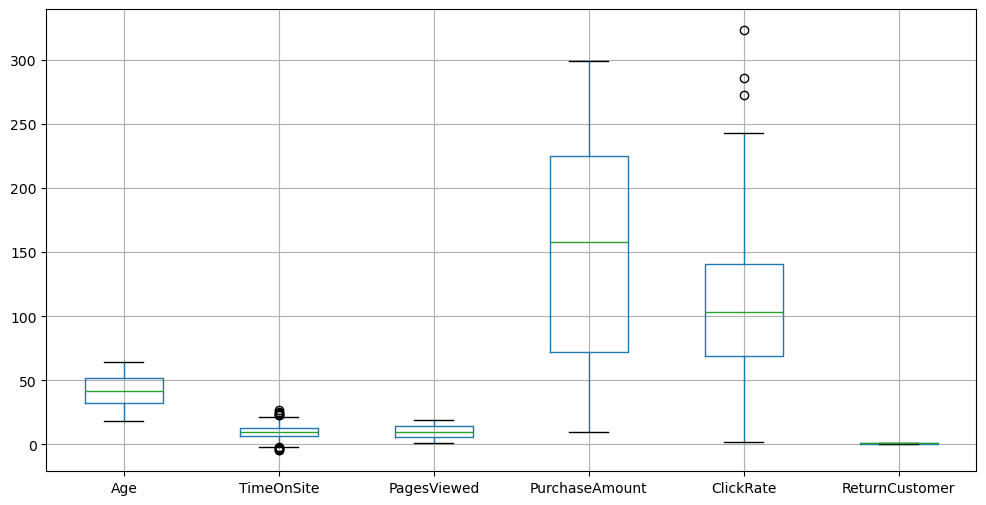

In [30]:
import matplotlib.pyplot as plt

dfc.boxplot(figsize=(12,6))
plt.show()

In [31]:
median_time = dfc.loc[dfc["TimeOnSite"] >= 0, "TimeOnSite"].median()
dfc.loc[dfc["TimeOnSite"] < 0, "TimeOnSite"] = median_time

In [32]:
dfc.sample(20)
dfc.duplicated().sum()

np.int64(0)

In [33]:
dfc.dtypes

Age               float64
Gender             object
TimeOnSite        float64
PagesViewed       float64
Device             object
PurchaseAmount    float64
DiscountUsed       object
ClickRate         float64
ReturnCustomer    float64
dtype: object

In [ ]:
dfc['Age'] = dfc['Age'].astype(int) 

dfc['PagesViewed'] = dfc['PagesViewed'].astype(int) 

dfc['ReturnCustomer'] = dfc['ReturnCustomer'].astype(int) 

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')

In [35]:
dfc.dtypes

Age                 int64
Gender             object
TimeOnSite        float64
PagesViewed         int64
Device             object
PurchaseAmount    float64
DiscountUsed       object
ClickRate         float64
ReturnCustomer      int64
dtype: object

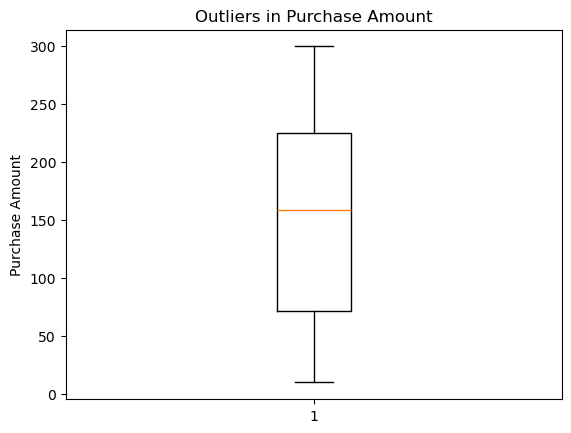

In [36]:
plt.boxplot(dfc['PurchaseAmount'])
plt.title("Outliers in Purchase Amount")
plt.ylabel("Purchase Amount")
plt.show()

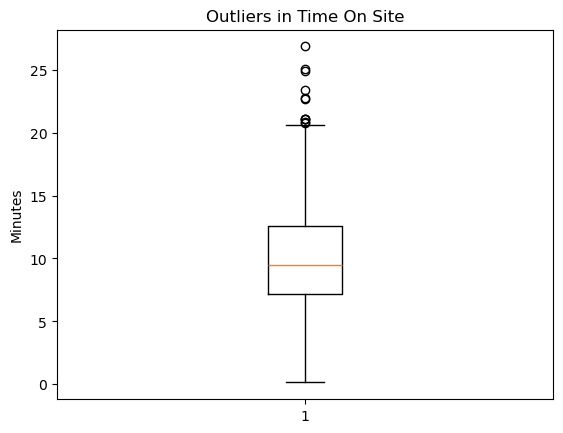

In [37]:
plt.boxplot(dfc['TimeOnSite'])
plt.title("Outliers in Time On Site")
plt.ylabel("Minutes")
plt.show()

In [38]:
Q1 = dfc['TimeOnSite'].quantile(0.25)
Q3 = dfc['TimeOnSite'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

median_time = dfc['TimeOnSite'].median()

dfc.loc[
    (dfc['TimeOnSite'] < lower) | (dfc['TimeOnSite'] > upper),
    'TimeOnSite'
] = median_time

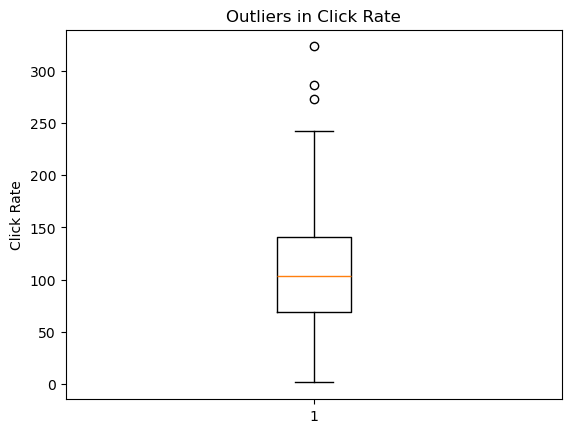

In [39]:
plt.boxplot(dfc['ClickRate'])
plt.title("Outliers in Click Rate")
plt.ylabel("Click Rate")
plt.show()

### Any Thing Above 20Minutes Is Outlier.

In [40]:
Q1 = dfc['ClickRate'].quantile(0.25)
Q3 = dfc['ClickRate'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

median_click = dfc['ClickRate'].median()

dfc.loc[
    (dfc['ClickRate'] < lower) | (dfc['ClickRate'] > upper),
    'ClickRate'
] = median_click

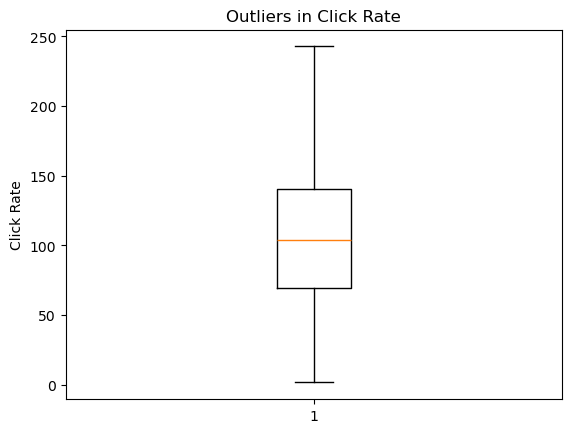

In [41]:
plt.boxplot(dfc['ClickRate'])
plt.title("Outliers in Click Rate")
plt.ylabel("Click Rate")
plt.show()

# 3. Perform Univariate and Bivariate Analysis.

# A.Compute summary statistics.

In [360]:
dfc.head(5)

,Age,Gender,TimeOnSite,PagesViewed,Device,PurchaseAmount,DiscountUsed,ClickRate,ReturnCustomer
0,63,Male,18.685621,3,Mobile,289.253886,Yes,35.878814,1
1,43,Female,4.411306,9,Desktop,224.366091,No,177.625321,0
2,35,Male,9.217575,17,Mobile,254.559993,Yes,42.648411,0
3,41,Female,13.183255,4,Desktop,66.949884,No,34.546995,1
4,41,Female,17.709027,3,Mobile,170.062225,Yes,56.095720,0


In [361]:
dfc.describe()

,Age,TimeOnSite,PagesViewed,PurchaseAmount,ClickRate,ReturnCustomer
count,567.000000,567.000000,567.000000,567.000000,567.000000,567.000000
mean,41.435626,9.767028,9.901235,152.933806,104.813552,0.559083
std,12.674186,4.277099,5.171010,86.301455,49.939202,0.496935
min,18.000000,0.145792,1.000000,10.051373,1.588604,0.000000
25%,32.000000,7.162593,6.000000,72.011192,69.248725,0.000000
50%,41.000000,9.508014,10.000000,158.236823,103.600830,1.000000
75%,52.000000,12.312299,14.000000,224.942620,140.364293,1.000000
max,64.000000,20.578767,19.000000,299.310595,242.790074,1.000000



 Age: The standard deviation is 12.67, which shows a noticeable spread around the mean age of 41.51, meaning users are fairly distributed across different age groups.

 TimeOnSite: With a standard deviation of 4.27 around a mean of 9.75, users show a moderate variation in how long they stay on the site.

 PagesViewed: The standard deviation i5.17 with a mean of 9.90, indicating that user browsing depth varies quite a bit between sessions.

 PurchaseAmount: A high standard deviation of 86.30 compared to a mean of **152.93** shows strong differences in customer spending behavior.

 ClickRate: The standard deviation is 49.94 around a mean of 104.79, suggesting that user engagement levels differ significantly.

 ReturnCustomer: The standard deviation is 0.49 with a mean of 0.56, which makes sense for a binary variable and shows a fairly balanced split between returning and new users.



# B. Visualize data distributions.

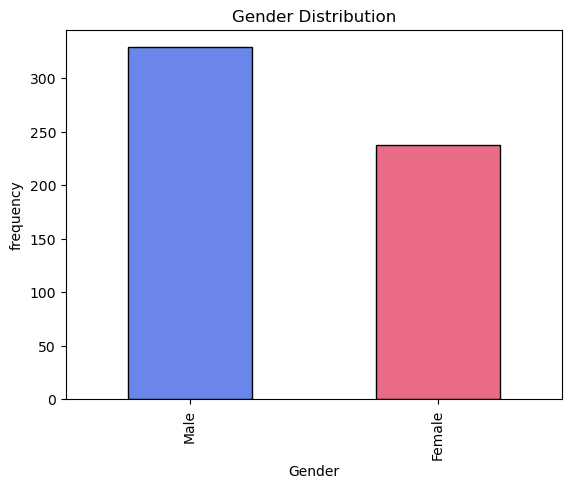

In [362]:
dfc["Gender"].value_counts().plot(kind="bar", color=['#6b86ea','#ea6b86'] , edgecolor='black')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("frequency")
plt.show()

Most of the customers are males.

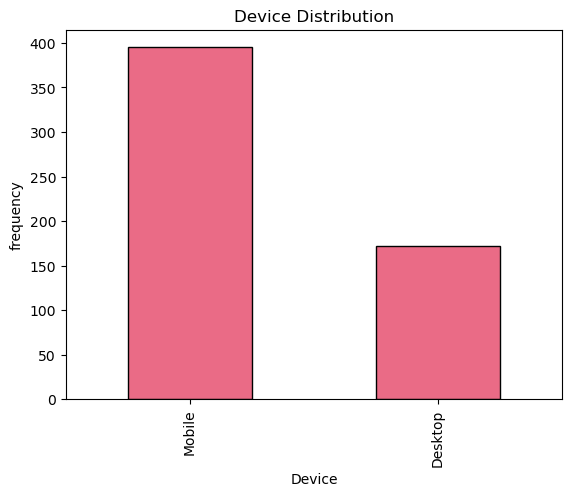

In [363]:

dfc["Device"].value_counts().plot(kind="bar", color="#ea6b86", edgecolor="black")
plt.title("Device Distribution")
plt.xlabel("Device")
plt.ylabel("frequency")
plt.show()

Most customers use mobile devices for their online shopping.

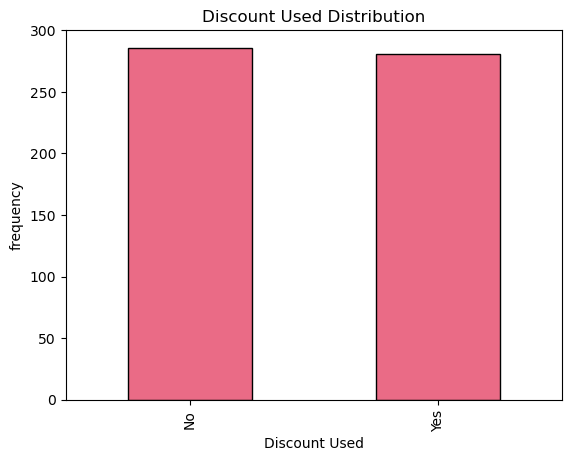

In [364]:

dfc["DiscountUsed"].value_counts().plot(kind="bar", color="#ea6b86", edgecolor="black")
plt.title("Discount Used Distribution")
plt.xlabel("Discount Used")
plt.ylabel("frequency")
plt.show()

Most customers are split almost equally between using and not using a discount.

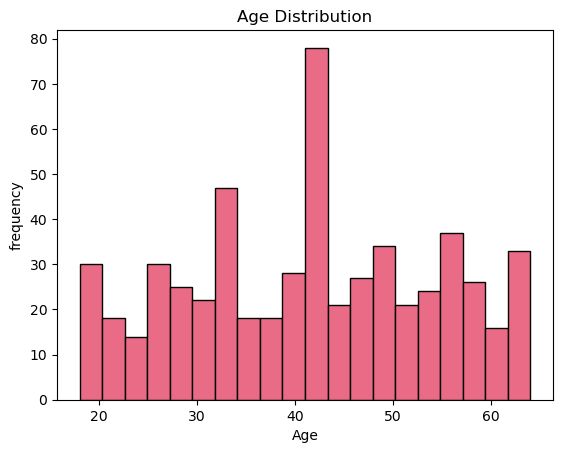

In [365]:
plt.hist(dfc['Age'], bins=20, edgecolor='black', color='#ea6b86')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("frequency")
plt.show()

Most people are between 41 and 43 years old.

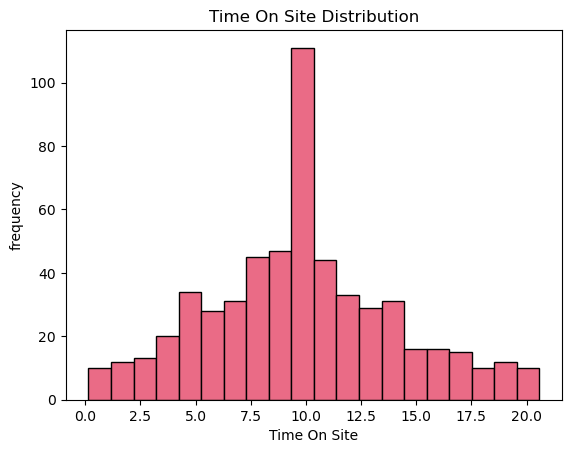

In [366]:
plt.hist(dfc['TimeOnSite'], bins=20, edgecolor='black', color='#ea6b86')
plt.title("Time On Site Distribution")
plt.xlabel("Time On Site")
plt.ylabel("frequency")
plt.show()

Most users spend about 10m on the site.

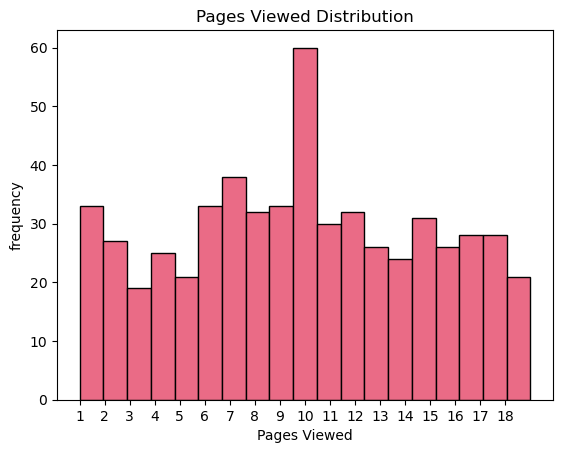

In [367]:
plt.hist(dfc['PagesViewed'], bins=19, edgecolor='black', color='#ea6b86')
plt.title("Pages Viewed Distribution")
plt.xlabel("Pages Viewed")
plt.ylabel("frequency")
plt.xticks(range(1, 19))
plt.show()

Most users view 10 pages per session.

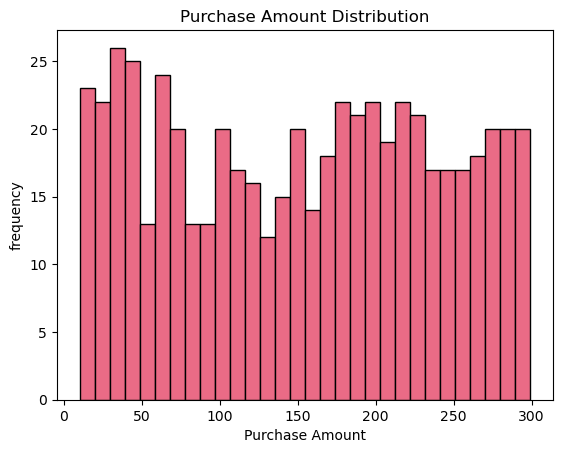

In [368]:
plt.hist(dfc['PurchaseAmount'], bins=30, edgecolor='black', color='#ea6b86')
plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("frequency")
plt.show()

Most users spend different amounts of money but the highest number of purchases is between 20 and 50.

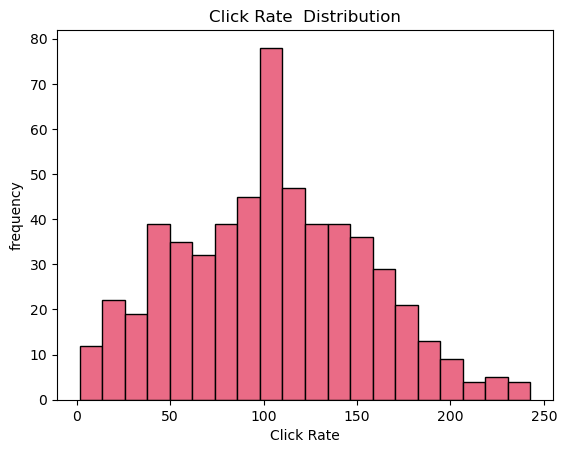

In [369]:
plt.hist(dfc['ClickRate'], bins=20, edgecolor='black', color='#ea6b86')
plt.title("Click Rate  Distribution")
plt.xlabel("Click Rate")
plt.ylabel("frequency")
plt.show()

Most users have a click rate of around 100.

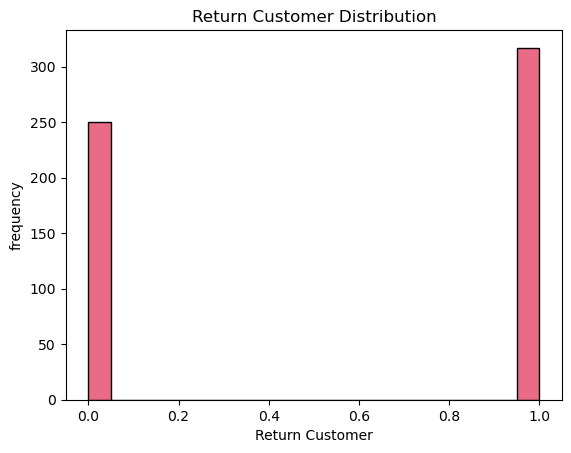

In [370]:
plt.hist(dfc['ReturnCustomer'], bins=20, edgecolor='black', color='#ea6b86')
plt.title("Return Customer Distribution")
plt.xlabel("Return Customer")
plt.ylabel("frequency")
plt.show()

Most users are return customers and they are represented by the value 1.

# C. Analyze relationships between variables. 

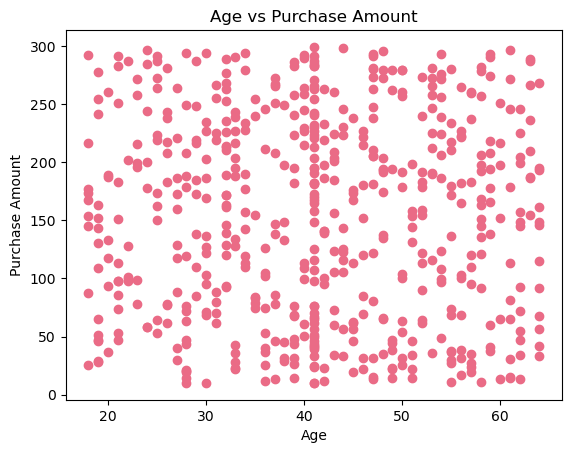

In [371]:
plt.scatter(dfc["Age"], dfc["PurchaseAmount"], color='#ea6b86')
plt.title("Age vs Purchase Amount")
plt.xlabel("Age")
plt.ylabel("Purchase Amount")
plt.show()

There is no clear relationship between age and purchase amount.

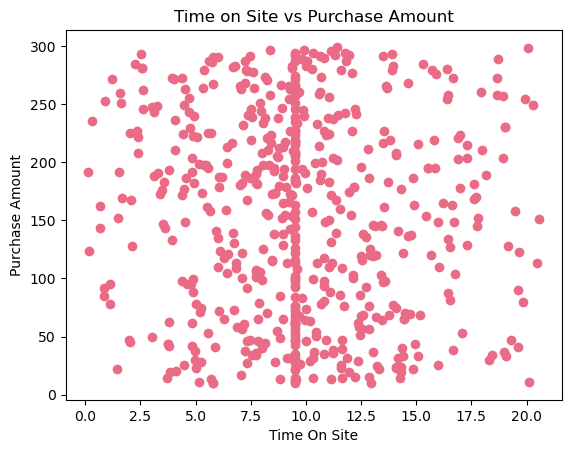

In [372]:
plt.scatter(dfc["TimeOnSite"], dfc["PurchaseAmount"] , color='#ea6b86')
plt.title("Time on Site vs Purchase Amount")
plt.xlabel("Time On Site")
plt.ylabel("Purchase Amount")
plt.show()

There is no clear relationship time between spent on the site and purchase amount.

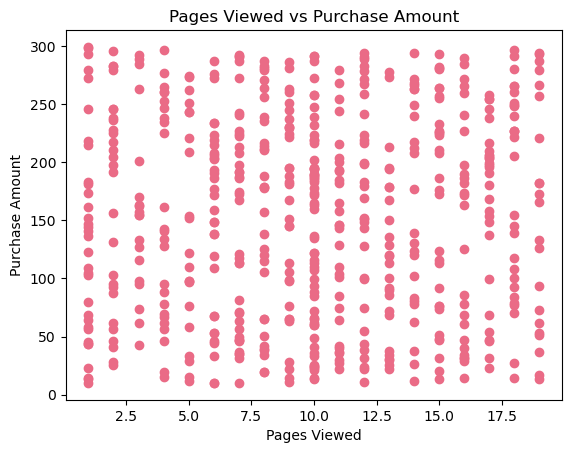

In [373]:
plt.scatter(dfc["PagesViewed"], dfc["PurchaseAmount"], color='#ea6b86')
plt.title("Pages Viewed vs Purchase Amount")
plt.xlabel("Pages Viewed")
plt.ylabel("Purchase Amount")
plt.show()

There is no clear relationship between the number of pages viewed and the purchase amount.

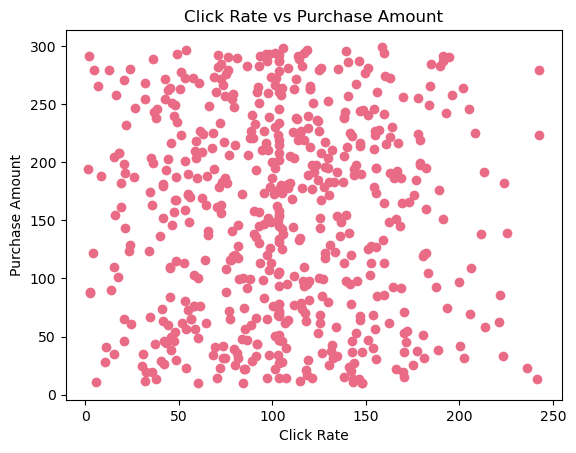

In [374]:
plt.scatter(dfc["ClickRate"], dfc["PurchaseAmount"] , color='#ea6b86')
plt.title("Click Rate vs Purchase Amount")
plt.xlabel("Click Rate")
plt.ylabel("Purchase Amount")
plt.show()

There is no clear relationship between click rate and purchase amount.

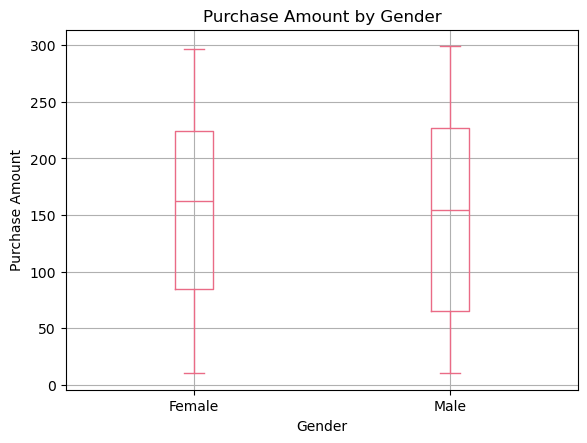

In [375]:
dfc.boxplot(column="PurchaseAmount", by="Gender", color='#ea6b86')
plt.title("Purchase Amount by Gender")
plt.suptitle("")
plt.xlabel("Gender")
plt.ylabel("Purchase Amount")
plt.show()

Median: F > M


Box Height: F < M


Total Range: almost F = M


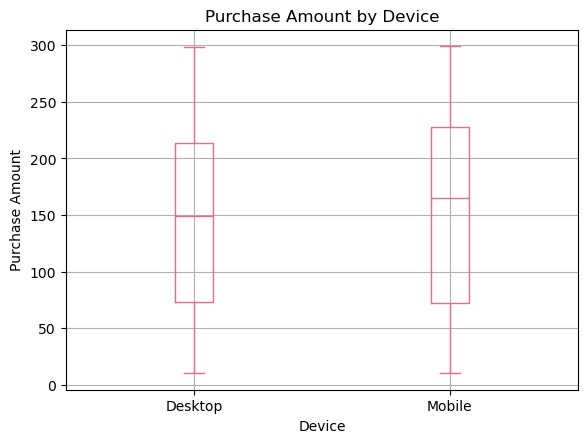

In [376]:
dfc.boxplot(column="PurchaseAmount", by="Device", color='#ea6b86')
plt.title("Purchase Amount by Device")
plt.suptitle("")
plt.xlabel("Device")
plt.ylabel("Purchase Amount")
plt.show()

Median: D < M

Box Height: D < M

Total Range: almost F = M

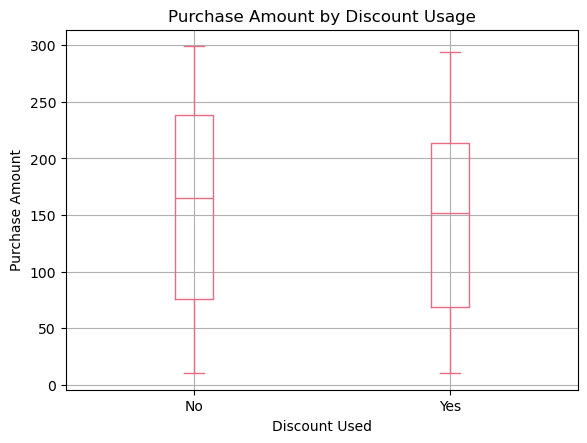

In [377]:
dfc.boxplot(column="PurchaseAmount", by="DiscountUsed", color='#ea6b86')
plt.title("Purchase Amount by Discount Usage")
plt.suptitle("")
plt.xlabel("Discount Used")
plt.ylabel("Purchase Amount")
plt.show()

Median: NO > YES

Box Height: NO > YES

Total Range: NO > YES

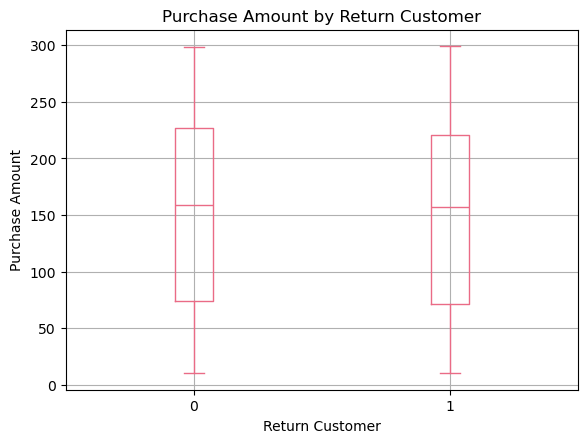

In [378]:
dfc.boxplot(column="PurchaseAmount", by="ReturnCustomer", color='#ea6b86')
plt.title("Purchase Amount by Return Customer")
plt.suptitle("")
plt.xlabel("Return Customer")
plt.ylabel("Purchase Amount")
plt.show()

Median: 0 = 1

Box Height: 0 > 1

Total Range: almost 0 = 1

# D. Evaluate correlations.

In [379]:
numeric_data = dfc.select_dtypes(include='number')
correlations = numeric_data.corr()
print(correlations)

                     Age  TimeOnSite  PagesViewed  PurchaseAmount  ClickRate  \
Age             1.000000    0.054108     0.033034       -0.012552  -0.044645   
TimeOnSite      0.054108    1.000000    -0.030192       -0.060644  -0.000070   
PagesViewed     0.033034   -0.030192     1.000000        0.035996   0.027811   
PurchaseAmount -0.012552   -0.060644     0.035996        1.000000  -0.010113   
ClickRate      -0.044645   -0.000070     0.027811       -0.010113   1.000000   
ReturnCustomer -0.044629   -0.007665    -0.006663       -0.010470   0.105045   

                ReturnCustomer  
Age                  -0.044629  
TimeOnSite           -0.007665  
PagesViewed          -0.006663  
PurchaseAmount       -0.010470  
ClickRate             0.105045  
ReturnCustomer        1.000000  


The correlation analysis shows mostly weak relationships between variables, indicating no strong linear dependencies. The only slight positive relationship is between ClickRate and ReturnCustomer, suggesting that more active users are a bit more likely to return.

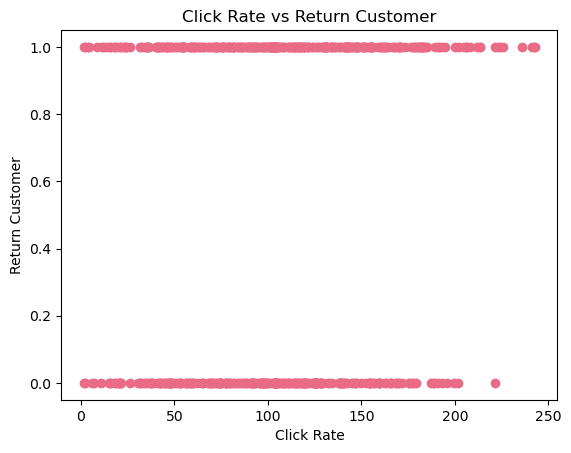

In [380]:
plt.scatter(dfc["ClickRate"], dfc["ReturnCustomer"], color='#ea6b86')
plt.title("Click Rate vs Return Customer")
plt.xlabel("Click Rate")
plt.ylabel("Return Customer")
plt.show()

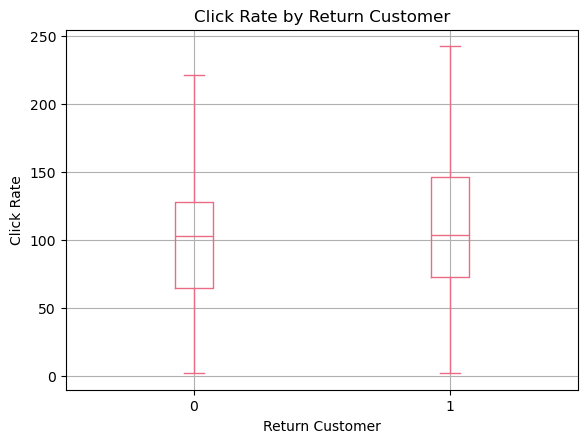

In [381]:
dfc.boxplot(column="ClickRate", by="ReturnCustomer", color='#ea6b86')
plt.title("Click Rate by Return Customer")
plt.suptitle("") 
plt.xlabel("Return Customer")
plt.ylabel("Click Rate")
plt.show()

Median: 0 = 1

Box Height: 0 < 1

Total Range: 0 < 1

In [382]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588 entries, 0 to 587
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              544 non-null    float64
 1   gender           560 non-null    object 
 2   time_on_site     540 non-null    float64
 3   pages_viewed     582 non-null    object 
 4   device           545 non-null    object 
 5   purchase_amount  586 non-null    float64
 6   discount_used    583 non-null    object 
 7   click_rate       583 non-null    float64
 8   return_customer  560 non-null    float64
dtypes: float64(5), object(4)
memory usage: 41.5+ KB


# 5. Interpret and Conclude

## 1. Dataset Overview

Exploring this dataset allows us to evaluate how variables such as age, gender, and device type correlate with shopping habits, providing actionable insights into customer loyalty and spending patterns.

This dataset comprises 588 customer records and 9 variables, integrating demographic profiles—such as age and gender—with behavioral and transactional metrics like time on site, click rate, and purchase amount to analyze e-commerce patterns.

## 2. Customer Behavior Analysis

Customer behavior analysis reveals that most users are approximately 42 years old, predominantly male, and prefer mobile devices, with a typical session involving 10 minutes on-site, 10 pages viewed, and a click rate of about 100.

## 3. Relationship Between Variables


The analysis showed weak relationships between most variables, meaning that customer purchase behavior was not strongly affected by a single factor alone.

## 4. Correlation Findings

Correlation analysis revealed mostly weak correlations, with a slight positive relationship between Click Rate and Return Customer, suggesting that more active users are slightly more likely to return.

## 5. Final Conclusion

This project helped us understand online customer behavior through data cleaning, visualization, and correlation analysis, and showed how customer interaction patterns can provide useful business insights.